# Introduction

Boeing is a company dedicated to the design, manufacture, and sale of aircraft, and is the world's second-largest manufacturer after Airbus. Its shares are traded on the NYSE under the ticker symbol BA, and it is a strategic company for the US due to its role as a defense contractor.

This is a dataset provided by the aerospace company Boeing, which stores the name, country, and category of its suppliers. The aim is to use this data for exploratory analysis to uncover insights.

# Preparation

In [365]:
# import libraries
        
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
# Download dataset
path = r"/kaggle/input/boeing-supplier-list/Boeing Supplier List.csv"

df = pd.read_csv(path)

In [367]:
# Visualize first and last items
print(df.head())
print(df.tail())

                       Supplier Country    Category
0                            3M     USA   Chemicals
1    3V Fasteners Company, Inc.     USA   Fasteners
2           A&B Aerospace, Inc.     USA  Components
3  Aadox Manufacturing Co, Inc.     USA   Fasteners
4      Accurate Bushing Company     USA    Bearings
                          Supplier Country      Category
391                   Western Wire     USA        Cables
392                       Woodward     USA  Fuel Systems
393                Young Engineers     USA    Components
394  Zeus Industrial Products, Inc     USA        Tubing
395            Zodiac Services/ECE  France    Components


In [368]:
# Visualize headers
print(df.columns)

Index(['Supplier', 'Country', 'Category'], dtype='object')


In [369]:
# Show dataframe size
print(df.shape)

(396, 3)


In [370]:
# Rename headers
df = df.rename(columns={
    'Supplier': 'supplier',
    'Country': 'country',
    'Category': 'category'
    })
print(df.columns)

Index(['supplier', 'country', 'category'], dtype='object')


In [371]:
# Visualize dataframe information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   supplier  396 non-null    object
 1   country   396 non-null    object
 2   category  396 non-null    object
dtypes: object(3)
memory usage: 9.4+ KB
None


In [372]:
print(df['supplier'].nunique())

392


## Observations

No missing or duplicate values ​​were found and the data type is correct

In [373]:
# Show supplier's country
print(df['country'].unique())

['USA' 'Netherlands' 'India' 'UK' 'France' 'Germany' 'Spain' 'Canada'
 'Belgium' 'Austria' 'Switzerland' 'Italy' 'Japan' 'Taiwan' 'Singapore'
 'Sweden']


To facilitate the location of supply chains in the analysis, suppliers are grouped by region.

In [374]:
# define function

def region_group(country):
     
     north_america ={'USA', 'Canada','Mexico'}
     europe = {'Netherlands', 'UK', 'France', 'Germany', 'Spain', 'Belgium', 'Austria', 'Switzerland', 'Italy', 'Sweden'}
     asia = {'India', 'Japan', 'Taiwan', 'Singapore'}

     if country in north_america:
        return 'north_america'
     elif country in europe:
        return 'europe'
     elif country in asia:
        return 'asia'
     else:
        return 'other'


In [375]:
# Add region_column for the analisis  
df['region_group'] = df['country'].apply(region_group)
print(df.head())

                       supplier country    category   region_group
0                            3M     USA   Chemicals  north_america
1    3V Fasteners Company, Inc.     USA   Fasteners  north_america
2           A&B Aerospace, Inc.     USA  Components  north_america
3  Aadox Manufacturing Co, Inc.     USA   Fasteners  north_america
4      Accurate Bushing Company     USA    Bearings  north_america


In [376]:
# Show supplier's categories
print(df['category'].unique())

['Chemicals' 'Fasteners' 'Components' 'Bearings' 'Seals' 'Lighting'
 'Electrical' 'Fittings' 'Materials' 'Coatings' 'Hardware' 'Lubrication'
 'Distribution' 'Seals/Tools' 'Connectors' 'Springs' 'Cables' 'Plastics'
 'Protective' 'Ignition' 'Antennas' 'Avionics/Interiors' 'Ceramics'
 'Switches' 'Composites' 'Hydraulics' 'Tools' 'Filters' 'Sealants'
 'Structural Parts' 'Batteries' 'Safety' 'Engines' 'Foam Cores' 'Mesh'
 'Aerostructures' 'Latches' 'Cable Mgmt' 'Adhesives' 'Composite Materials'
 'Avionics/Systems' 'Sensors' 'Surface Finishing' 'Composites (WA)'
 'Lighting Systems' 'Metals' 'Relays' 'Valves' 'Landing Gear' 'Fuses'
 'Controls' 'Brakes/Sensors' 'Flight Controls' 'Tapes' 'Fluids'
 'Packaging' 'Fluid Systems' 'Engine Components' 'Fabrics' 'Enclosures'
 'Prepregs' 'Prepregs (777X)' 'Tubing' 'Rings' 'Advanced Materials'
 'Fuselages/Wings' 'Pins' 'Carbon Fiber' 'Carbon Fiber (WA)'
 'Wing Components' 'Structures/Systems' 'Fuel Systems']


In [377]:
# Show supplier by country
supplier_by_country = df.groupby('country')['category'].count().sort_values(ascending=False)
print(supplier_by_country)
supplier_by_country_pct = df['country'].value_counts(normalize=True)
print(supplier_by_country_pct)

country
USA            324
France          18
UK              15
Germany         12
Japan            4
Belgium          3
Canada           3
India            3
Italy            3
Netherlands      3
Switzerland      3
Austria          1
Singapore        1
Spain            1
Sweden           1
Taiwan           1
Name: category, dtype: int64
country
USA            0.818182
France         0.045455
UK             0.037879
Germany        0.030303
Japan          0.010101
Netherlands    0.007576
India          0.007576
Canada         0.007576
Belgium        0.007576
Switzerland    0.007576
Italy          0.007576
Spain          0.002525
Austria        0.002525
Taiwan         0.002525
Singapore      0.002525
Sweden         0.002525
Name: proportion, dtype: float64


C:\Users\Pablo\AppData\Local\Temp\ipykernel_15348\2038862135.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='country', order=df['country'].value_counts().index, palette='muted')


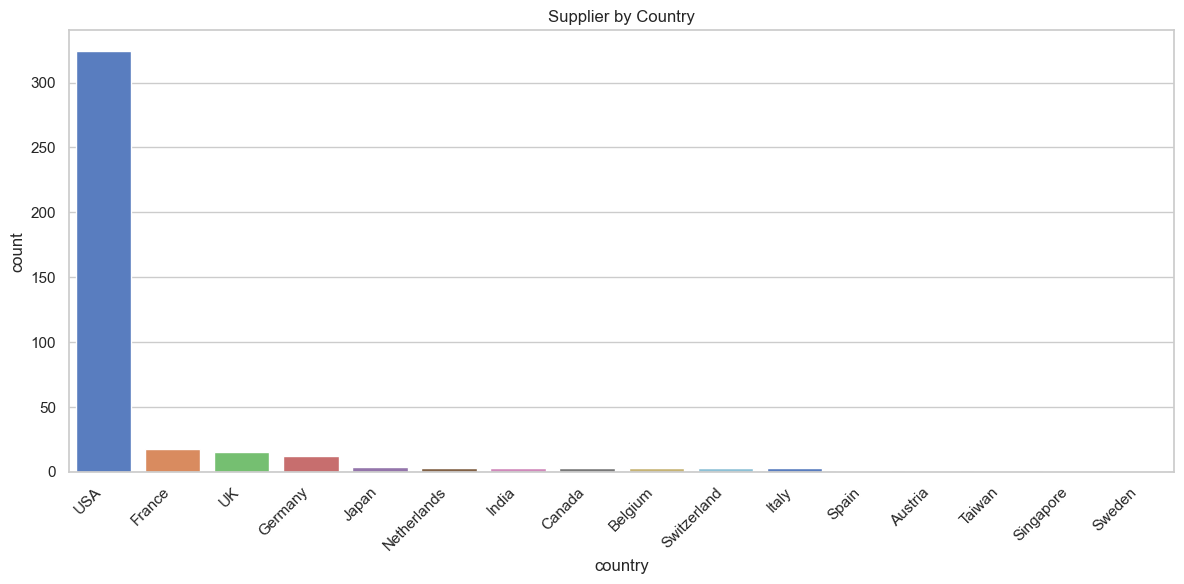

In [378]:
#Plot a count plot for supplier by country
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='country', order=df['country'].value_counts().index, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Supplier by Country')
plt.tight_layout()
plt.show()

In [379]:
# Show supplier by category
supplier_by_category = df['category'].value_counts()
print(supplier_by_category.head(20))

category
Components      77
Fasteners       61
Seals           27
Bearings        20
Hardware        18
Lighting        16
Distribution    13
Chemicals       12
Connectors      11
Materials       11
Fittings        10
Electrical      10
Coatings         7
Safety           7
Engines          5
Metals           4
Composites       4
Tools            4
Cables           4
Plastics         4
Name: count, dtype: int64


C:\Users\Pablo\AppData\Local\Temp\ipykernel_15348\2421569521.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', order=df['category'].value_counts().index, palette='muted')


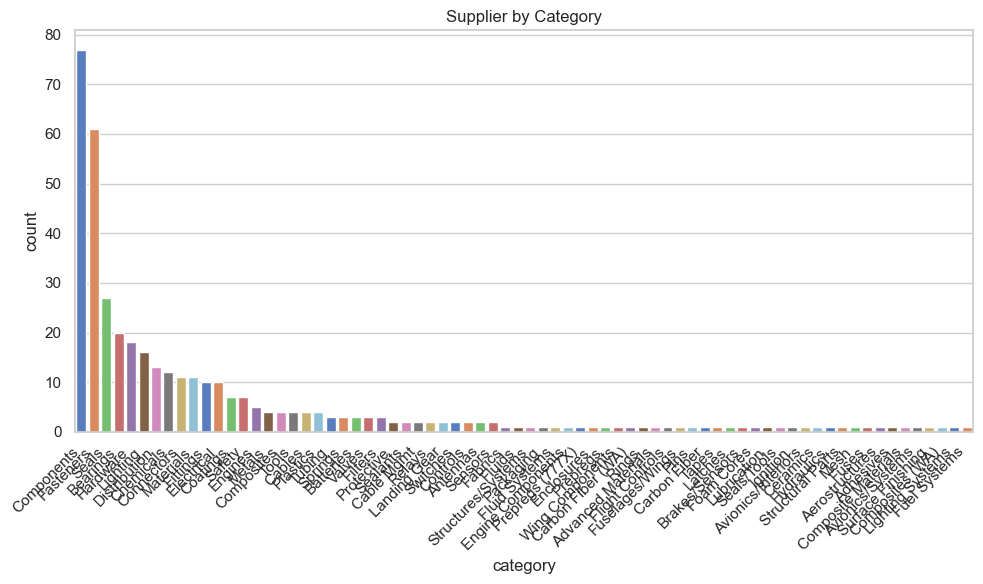

In [380]:
#Plot a count plot for supplier by category
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Supplier by Category')
plt.tight_layout()
plt.show()

Because the supplier categories are very numerous, and in order to facilitate the analysis, they will be analyzed by subcategories.

In [381]:
# define function

def subcategory(category):

    raw_materials = {'Metals', 'Ceramics', 'Plastics', 'Fabrics', 'Carbon Fiber', 'Carbon Fiber (WA)', 'Advanced Materials', 'Composite Materials', 'Composites', 'Composites (WA)', 'Prepregs', 'Prepregs (777X)', 'Foam Cores','Mesh'}
    structures = {'Aerostructures','Fuselages/Wings', 'Wing Components', 'Structural Parts', 'Landing Gear', 'Brakes/Sensors', 'Flight Controls', 'Controls','Structures/Systems'}
    mechanical_components = {'Bearings', 'Springs', 'Seals', 'Seals/Tools', 'Rings', 'Pins', 'Latches', 'Valves', 'Filters', 'Tubing', 'Fittings', 'Fasteners', 'Hardware'}
    electrical_electronics = {'Electrical', 'Cables', 'Cable Mgmt', 'Connectors', 'Relays', 'Switches', 'Fuses', 'Batteries', 'Sensors', 'Antennas', 'Ignition', 'Lighting', 'Lighting Systems'}
    avionics_systems = {'Avionics/Systems', 'Avionics/Interiors'}
    fluid_systems = {'Hydraulics', 'Fluid Systems', 'Fuel Systems', 'Fluids', 'Lubrication', 'Sealants'}
    chemicals_surface = {'Chemicals', 'Coatings', 'Adhesives', 'Tapes', 'Surface Finishing', 'Protective'}
    engines = {'Engines', 'Engine Components'}
    support_logistics = {'Distribution', 'Packaging', 'Tools', 'Enclosures'}
    safety = {'Safety'}

    if category in raw_materials:
        return 'raw_materials'
    elif category in structures:
        return 'structures'
    elif category in mechanical_components:
        return 'mechanical_components'
    elif category in electrical_electronics:
        return 'electrical_electronics'
    elif category in avionics_systems:
        return 'avionics_systems'
    elif category in fluid_systems:
        return 'fluid_systems'
    elif category in chemicals_surface:
        return 'chemicals_surface'
    elif category in engines:
        return 'engines'
    elif category in support_logistics:
        return 'support_logistics'
    else:
        return 'safety'
    


In [382]:
# Add subcategory for the analisis  
df['subcategory'] = df['category'].apply(subcategory)
print(df.head())

                       supplier country    category   region_group  \
0                            3M     USA   Chemicals  north_america   
1    3V Fasteners Company, Inc.     USA   Fasteners  north_america   
2           A&B Aerospace, Inc.     USA  Components  north_america   
3  Aadox Manufacturing Co, Inc.     USA   Fasteners  north_america   
4      Accurate Bushing Company     USA    Bearings  north_america   

             subcategory  
0      chemicals_surface  
1  mechanical_components  
2                 safety  
3  mechanical_components  
4  mechanical_components  


In [383]:
# Show supplier by subcategory
supplier_by_subcategory = df['subcategory'].value_counts()
print(supplier_by_subcategory.head(10))

subcategory
mechanical_components     152
safety                     95
electrical_electronics     57
chemicals_surface          24
raw_materials              23
support_logistics          19
structures                 11
fluid_systems               7
engines                     6
avionics_systems            2
Name: count, dtype: int64


C:\Users\Pablo\AppData\Local\Temp\ipykernel_15348\2138647584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='subcategory', order=df['subcategory'].value_counts().index, palette='muted')


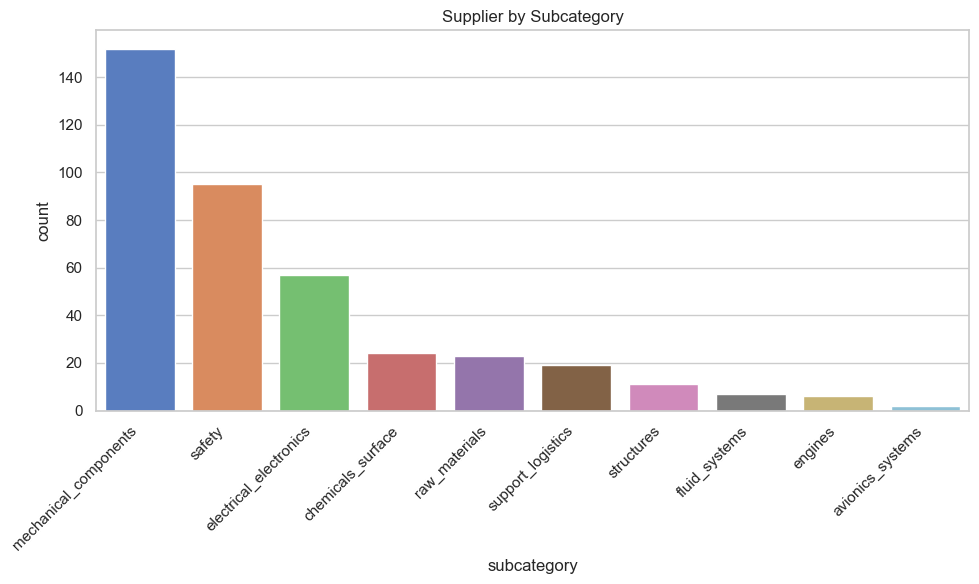

In [384]:
#Plot a count plot for supplier by subcategory
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='subcategory', order=df['subcategory'].value_counts().index, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Supplier by Subcategory')
plt.tight_layout()
plt.show()

In [385]:
# Show supplier by region
supplier_by_region = df.groupby('region_group')['region_group'].count().sort_values(ascending=False)
print(supplier_by_region)

region_group
north_america    327
europe            60
asia               9
Name: region_group, dtype: int64


C:\Users\Pablo\AppData\Local\Temp\ipykernel_15348\713872542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region_group', order=df['region_group'].value_counts().index, palette='muted')


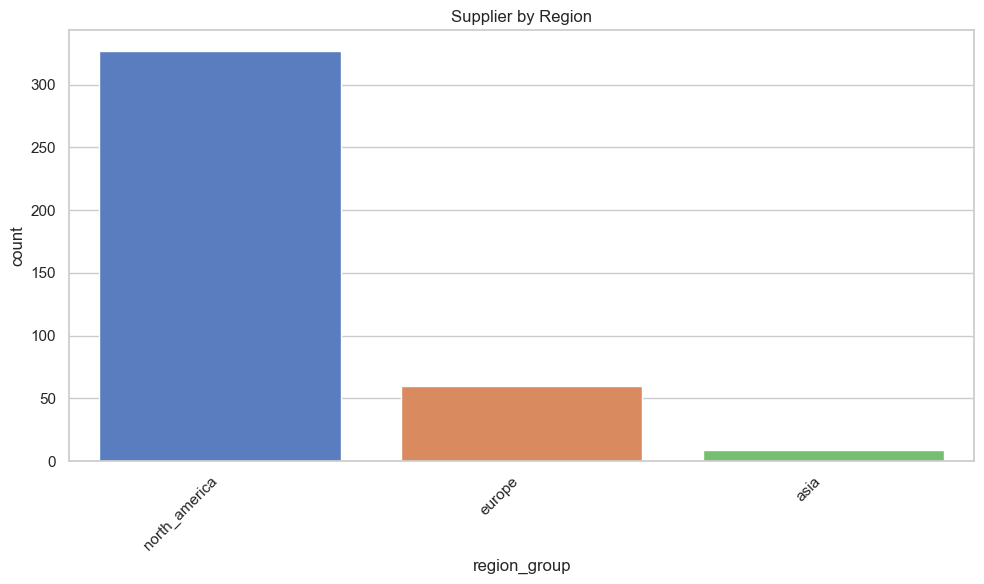

In [386]:
#Plot a count plot for supplier by region
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='region_group', order=df['region_group'].value_counts().index, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Supplier by Region')
plt.tight_layout()
plt.show()


In [ ]:
# Counts suppliers by subcategory divided by region
print(df.groupby('region_group')['subcategory'].value_counts())

region_group   subcategory           
asia           electrical_electronics      3
               mechanical_components       3
               chemicals_surface           2
               safety                      1
europe         mechanical_components      19
               safety                     14
               electrical_electronics     10
               chemicals_surface           6
               raw_materials               4
               structures                  4
               engines                     2
               fluid_systems               1
north_america  mechanical_components     130
               safety                     80
               electrical_electronics     44
               raw_materials              19
               support_logistics          19
               chemicals_surface          16
               structures                  7
               fluid_systems               6
               engines                     4
               av

# Conclusions

Boeing's three largest suppliers are from the following subcategories:
- mechanical components
- safety
- electrical electronics

Boeing primarily selects its suppliers from these regions in the following order:
- North America
- Europe
- Asia
- Boeing does not have suppliers from other geographic regions.

The main countries that supply Boeing are:
- USA 81%
- France 4%
- UK 3%
- Germany 3%
- Japan 1%

There are two subcategories in which Boeing sources exclusively from North America:
- support logistics
- avionics systems

The analysis could have been more comprehensive with access to expenditure amounts by category, payment methods, supplier financing terms, order dates, and delivery dates.
